# Occlusion

Sections 1-3 measured the detector on fruit an annotator could see whole. A phone
in a greenhouse is pointed at fruit behind leaves, behind other fruit, half out
of frame. This section asks what that costs, and - the part the earlier sections
set up - whether it costs the same thing everywhere.

Three measurements:

1. **Synthetic sweep.** Hide a known fraction of every annotated fruit and watch
   detection, staging and counting separately.
2. **Colour-directed occlusion.** A half-ripened fruit is red on one side and
   green on the other. Hide the red half, hide the green half: same fruit, same
   fraction, opposite colour evidence.
3. **Natural occlusion.** No pasting at all - fruit that other fruit already
   overlap in the original frames.

Model and data are the ones from section 3: `runs/cross_laboro3`, Laboro's own
161-image validation split, conf 0.25.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

RUNS = Path("../runs/occlusion")
STAGES = ["green", "half_ripened", "fully_ripened"]
SHORT = {"green": "green", "half_ripened": "half", "fully_ripened": "fully"}

strict = json.loads((RUNS / "laboro3_laboro3_leaf_iou50.json").read_text())
loose = json.loads((RUNS / "laboro3_laboro3_leaf_iou30.json").read_text())
print(f"{strict['n_images']} images, {strict['levels'][0]['n_gt']} annotated fruit, "
      f"conf {strict['conf']}, occluder {strict['occluder']}")

161 images, 1996 annotated fruit, conf 0.25, occluder leaf


## How the occluder is built

The strip runs in from one side of the box and covers a set fraction of its area,
so "40% hidden" means the same thing for a large fruit and a small one. The
patch itself is cropped from a fruit-free part of the same frame, which carries
that frame's lighting and white balance with it - a flat rectangle of any colour
would be a novel object rather than a leaf. `--occluder black` keeps the flat
version as a control.

clean.jpg


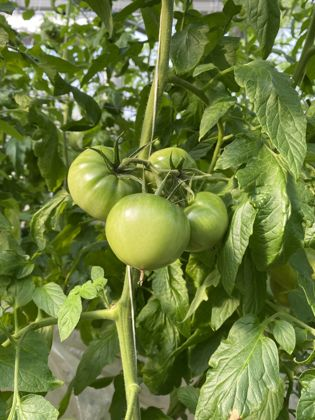

random_leaf_40.jpg


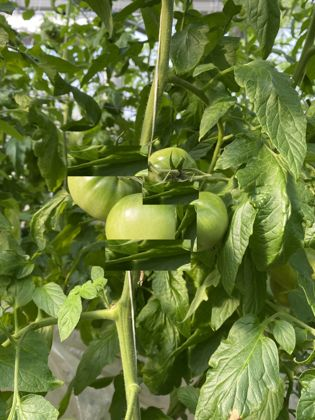

hide_red_leaf_40.jpg


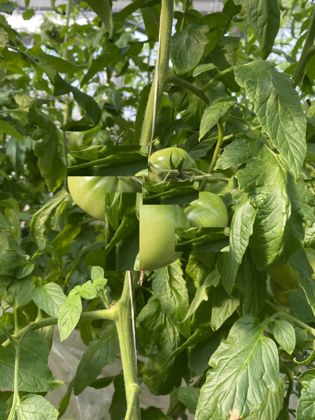

In [2]:
from io import BytesIO

from IPython.display import Image, display
from PIL import Image as PILImage

for name in ["clean.jpg", "random_leaf_40.jpg", "hide_red_leaf_40.jpg"]:
    path = RUNS / "examples" / name
    if not path.exists():
        continue
    thumb = PILImage.open(path)
    thumb.thumbnail((420, 420))
    buffer = BytesIO()
    thumb.save(buffer, format="JPEG", quality=80)
    print(name)
    display(Image(data=buffer.getvalue()))

## 1. What breaks first

Ground truth stays the whole fruit, occluded or not, so recall answers "did it
find the fruit" rather than "did it find the visible part". Stage accuracy is
computed only over fruit that were found, which keeps the two failures apart.

In [3]:
def table(document, mode):
    rows = [r for r in document["levels"] if r["mode"] in ("none", mode)]
    print(f"{'hidden':>7}{'recall':>9}{'green':>8}{'half':>7}{'fully':>7}"
          f"{'stage-acc':>11}{'conf':>7}{'MAE':>7}")
    for row in rows:
        by_stage = "".join(f"{row['recall_by_stage'][s]:>8.2f}" if s == "green"
                           else f"{row['recall_by_stage'][s]:>7.2f}" for s in STAGES)
        print(f"{row['fraction'] * 100:>6.0f}%{row['recall']:>9.3f}{by_stage}"
              f"{row['stage_accuracy']:>11.3f}{row['mean_conf']:>7.3f}"
              f"{row['counting_mae']:>7.2f}")

table(strict, "random")

 hidden   recall   green   half  fully  stage-acc   conf    MAE
     0%    0.884    0.87   0.90   0.93      0.944  0.840   1.25
    10%    0.837    0.81   0.86   0.91      0.940  0.825   1.25
    20%    0.778    0.75   0.79   0.87      0.940  0.797   1.33
    30%    0.694    0.65   0.73   0.82      0.931  0.768   1.49
    40%    0.571    0.52   0.63   0.71      0.920  0.737   1.77
    50%    0.312    0.30   0.30   0.36      0.923  0.677   2.06
    60%    0.160    0.15   0.17   0.19      0.900  0.606   2.43
    70%    0.057    0.05   0.05   0.08      0.860  0.506   2.99


Detection and staging come apart. Recall falls by an order of magnitude
across the sweep while stage accuracy barely moves - the model stops *finding*
fruit long before it starts misreading ripeness. Counting-MAE, the metric this
thesis is about, is driven almost entirely by the first of those, which is the
same point section 3 made about domain shift: a single error number cannot say
which mechanism produced it.

The per-stage columns rank the way the colour argument predicts: `fully` survives
occlusion best and `green` worst, on a dataset where green fruit are also the
smallest and the most numerous.

The zero-occlusion row is a check rather than a result: counting-MAE 1.25 is the
laboro3/Laboro cell of section 3's matrix, reproduced by a different code path.

### The cliff at 50% is bookkeeping, not perception

Recall drops off a shelf between 40% and 50% hidden. That is where the geometry
of the metric turns over, not the model: ground truth is the whole fruit, a
detector that boxes only the visible part scores IoU about `1 - fraction`
against it, and at 50% that lands exactly on the matching threshold. Re-running
the identical sweep at IoU 0.3 separates "did not find it" from "found it,
boxed what was left".

In [4]:
print(f"{'hidden':>7}{'recall @0.5':>13}{'recall @0.3':>13}{'MAE @0.5':>10}{'MAE @0.3':>10}")
for row in [r for r in loose["levels"] if r["mode"] in ("none", "random")]:
    twin = next(r for r in strict["levels"]
                if r["mode"] == row["mode"] and r["fraction"] == row["fraction"])
    print(f"{row['fraction'] * 100:>6.0f}%{twin['recall']:>13.3f}{row['recall']:>13.3f}"
          f"{twin['counting_mae']:>10.2f}{row['counting_mae']:>10.2f}")

 hidden  recall @0.5  recall @0.3  MAE @0.5  MAE @0.3
     0%        0.884        0.895      1.25      1.25
    30%        0.694        0.726      1.49      1.49
    40%        0.571        0.642      1.77      1.77
    50%        0.312        0.516      2.06      2.06
    60%        0.160        0.344      2.43      2.43
    70%        0.057        0.094      2.99      2.99


Counting-MAE is identical in the two runs, as it must be - counts do not
depend on how detections are matched to ground truth - which makes the pair a
clean decomposition. Both curves belong in the write-up: the strict one is the
honest answer to "is the fruit localised", the loose one to "is it seen at all".

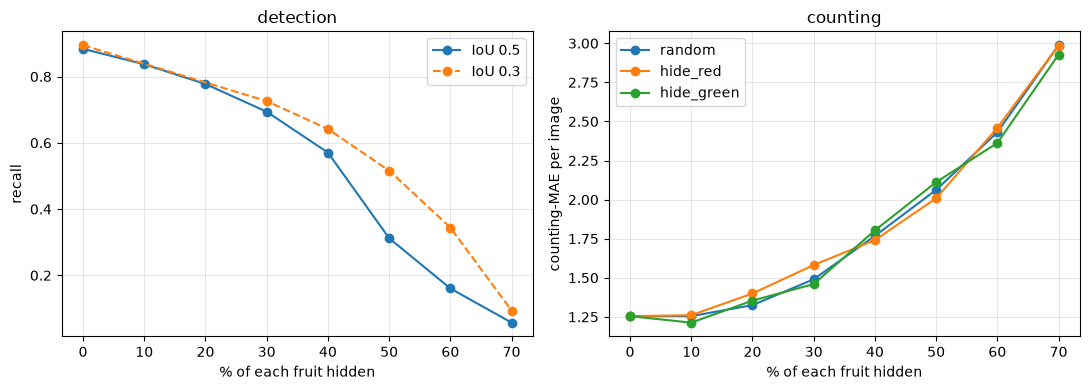

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for document, label, style in ((strict, "IoU 0.5", "-"), (loose, "IoU 0.3", "--")):
    rows = sorted([r for r in document["levels"] if r["mode"] in ("none", "random")],
                  key=lambda r: r["fraction"])
    axes[0].plot([r["fraction"] * 100 for r in rows], [r["recall"] for r in rows],
                 style, marker="o", label=label)
axes[0].set(xlabel="% of each fruit hidden", ylabel="recall", title="detection")
axes[0].legend(); axes[0].grid(alpha=0.3)

for mode in ("random", "hide_red", "hide_green"):
    rows = sorted([r for r in strict["levels"] if r["mode"] in ("none", mode)],
                  key=lambda r: r["fraction"])
    axes[1].plot([r["fraction"] * 100 for r in rows],
                 [r["counting_mae"] for r in rows], marker="o", label=mode)
axes[1].set(xlabel="% of each fruit hidden", ylabel="counting-MAE per image",
            title="counting")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RUNS / "curves.png", dpi=120)
plt.show()

## 2. Hiding the red half against hiding the green half

Same fruit, same fraction, opposite evidence. `hide_red` covers the redder half
of each box, `hide_green` the greener one, chosen by median CIELAB a\* - the axis
`cross_dataset/colour_stages.py` measured the stage boundaries on.

If the model reads ripeness off the visible colour, the two should push the stage
call in opposite directions; if it reads shape, size or context instead, they
should not differ.

In [6]:
for mode in ("hide_red", "hide_green"):
    print(f"--- {mode} ---")
    table(strict, mode)
    print()

--- hide_red ---
 hidden   recall   green   half  fully  stage-acc   conf    MAE
     0%    0.884    0.87   0.90   0.93      0.944  0.840   1.25
    10%    0.837    0.81   0.86   0.90      0.938  0.822   1.26
    20%    0.768    0.75   0.76   0.85      0.942  0.798   1.40
    30%    0.686    0.66   0.68   0.77      0.936  0.765   1.58
    40%    0.551    0.54   0.52   0.63      0.945  0.740   1.74
    50%    0.300    0.32   0.23   0.28      0.943  0.683   2.01
    60%    0.157    0.17   0.14   0.14      0.943  0.596   2.46
    70%    0.063    0.06   0.08   0.04      0.904  0.533   2.99

--- hide_green ---
 hidden   recall   green   half  fully  stage-acc   conf    MAE
     0%    0.884    0.87   0.90   0.93      0.944  0.840   1.25
    10%    0.843    0.82   0.87   0.91      0.939  0.824   1.21
    20%    0.783    0.75   0.83   0.88      0.935  0.797   1.35
    30%    0.699    0.63   0.79   0.86      0.928  0.766   1.46
    40%    0.587    0.51   0.71   0.78      0.919  0.737   1.80
   

In [7]:
from math import comb

RANK = {stage: index for index, stage in enumerate(STAGES)}

flip = json.loads((RUNS / "colour_flip_laboro3_laboro3_40.json").read_text())
print(f"paired, {int(flip['fraction'] * 100)}% hidden; stage scale green 0, half 1, fully 2")
print(f"{'GT stage':<10}{'n':>6}{'red hidden':>13}{'green hidden':>15}{'shift':>9}"
      f"{'disagree':>11}")
for stage, row in flip["by_stage"].items():
    print(f"{SHORT[stage]:<10}{row['n']:>6}{row['mean_hide_red']:>13.3f}"
          f"{row['mean_hide_green']:>15.3f}{row['shift']:>+9.3f}"
          f"{row['disagreement']:>11.1%}")

# McNemar over discordant pairs: fruit whose call moved up the ripeness scale when
# the green half was hidden, against those that moved down.
print()
for stage in STAGES:
    up = down = 0
    for key, count in flip["flips"].get(stage, {}).items():
        red_call, green_call = key.split("->")
        if RANK[green_call] > RANK[red_call]:
            up += count
        elif RANK[green_call] < RANK[red_call]:
            down += count
    total = up + down
    if not total:
        continue
    tail = sum(comb(total, k) for k in range(max(up, down), total + 1)) / 2 ** total
    print(f"{SHORT[stage]:<8} riper when green hidden: {up:>3}   "
          f"riper when red hidden: {down:>3}   two-sided p = {min(1.0, 2 * tail):.3f}")

paired, 40% hidden; stage scale green 0, half 1, fully 2
GT stage       n   red hidden   green hidden    shift   disagree
green        493        0.010          0.018   +0.008       1.8%
half         156        1.122          1.205   +0.083      17.3%
fully        187        1.941          1.957   +0.016       4.8%

green    riper when green hidden:   6   riper when red hidden:   3   two-sided p = 0.508
half     riper when green hidden:  20   riper when red hidden:   7   two-sided p = 0.019
fully    riper when green hidden:   6   riper when red hidden:   3   two-sided p = 0.508


The aggregate sweep above showed almost nothing between the two modes. Paired,
it separates: **which half is hidden decides the stage of a half-ripened fruit
and almost nothing else.** 17% of half-ripened fruit change their call between
the two conditions, against 2% of green and 5% of fully ripened ones - the
classes that look the same from either side. The direction is the one the colour
boundaries predict: among the half-ripened fruit that moved, close to three times
as many read riper with the green side covered as the other way round.

The mean shift is small (+0.08 of a stage) because most fruit do not move at all,
and that is the honest way to report it: the effect is concentrated in the class
that has two colours to choose between, which is also the class section 3 found
the two datasets disagreeing about.

Caveats: only fruit detected in *both* passes are compared, which selects the
easier ones; the two conditions remove different pixels beyond colour, including
specular highlights; and splitting a box by median a\* is a coarse stand-in for
"the red side".

## 3. Occlusion that was already there

Fruit overlapping other fruit, measured on the untouched frames: for every
annotated box, the share of its area covered by other annotated boxes. It is a
lower bound on what is hidden - leaves and stems carry no labels, and box overlap
does not know which fruit is in front - and it is real rather than pasted.

In [8]:
natural = json.loads((RUNS / "natural_laboro3_laboro3.json").read_text())
print(f"{'covered by other fruit':<24}{'n':>7}{'recall':>9}{'stage-acc':>11}{'conf':>8}")
for row in natural["rows"]:
    print(f"{row['bin']:<24}{row['n']:>7}{row['recall']:>9.3f}"
          f"{row['stage_accuracy']:>11.3f}{row['mean_conf']:>8.3f}")

covered by other fruit        n   recall  stage-acc    conf
none                        423    0.891      0.947   0.821
0-5%                        149    0.913      0.949   0.865
5-15%                       377    0.912      0.968   0.874
15-30%                      503    0.913      0.939   0.860
30-50%                      357    0.888      0.934   0.822
>50%                        187    0.701      0.908   0.751


Naturally overlapped fruit are barely harder than isolated ones: recall
holds within a point or two out to 50% box coverage and only falls past that.
The synthetic sweep, at the same nominal fraction, has already lost a third of
its detections. Two readings, and they are not exclusive:

- **The proxy overstates occlusion.** Fruit are round and boxes are rectangles,
  so two boxes can overlap by a third while neither fruit hides any of the other.
  Whatever "30-50% covered" means here, it is not "a third of the fruit is
  invisible".
- **The occluder is out of distribution.** Fruit behind fruit is in the training
  set; a pasted rectangle with a straight edge is not. Some of the synthetic
  damage may be the model reacting to the patch rather than to the missing
  pixels - which is what the `black` control is for, and what a fruit-shaped or
  leaf-shaped occluder would test.

Either way the gap is the finding, and it lands on the same nerve as section 3:
a protocol that hides a fixed fraction with a pasted patch is not measuring
robustness to occlusion, it is measuring reaction to an occluder. The number it
produces is not wrong, but it is not the field number either.

## 4. Two controls

**Does the occluder matter?** `--occluder black` pastes a flat black rectangle
instead of a crop of the frame's own background. Same geometry, same fraction,
different appearance.

**Does the checkpoint matter?** The same sweep with `runs/cross_mix`, the model
that actually ships in the app - trained on both datasets rather than on Laboro
alone.

In [9]:
black = json.loads((RUNS / "laboro3_laboro3_black_iou50.json").read_text())
mix = json.loads((RUNS / "mix_laboro3_leaf_iou50.json").read_text())


def curve(document):
    return {r["fraction"]: r for r in document["levels"] if r["mode"] in ("none", "random")}

leaf_c, black_c, mix_c = curve(strict), curve(black), curve(mix)
print(f"{'hidden':>7}{'leaf':>9}{'black':>9}{'mix/leaf':>11}   "
      f"{'MAE leaf':>9}{'MAE black':>10}{'MAE mix':>9}")
for fraction in sorted(set(leaf_c) & set(black_c) & set(mix_c)):
    print(f"{fraction * 100:>6.0f}%{leaf_c[fraction]['recall']:>9.3f}"
          f"{black_c[fraction]['recall']:>9.3f}{mix_c[fraction]['recall']:>11.3f}   "
          f"{leaf_c[fraction]['counting_mae']:>9.2f}"
          f"{black_c[fraction]['counting_mae']:>10.2f}"
          f"{mix_c[fraction]['counting_mae']:>9.2f}")

 hidden     leaf    black   mix/leaf    MAE leaf MAE black  MAE mix
     0%    0.884    0.884      0.878        1.25      1.25     1.14
    10%    0.837    0.820      0.839        1.25      1.29     1.06
    20%    0.778    0.709      0.770        1.33      1.43     1.18
    30%    0.694    0.609      0.668        1.49      1.72     1.42
    40%    0.571    0.461      0.554        1.77      1.88     1.69
    50%    0.312    0.148      0.286        2.06      2.20     2.04
    60%    0.160    0.091      0.136        2.43      2.53     2.49
    70%    0.057    0.047      0.040        2.99      2.98     3.11


The black patch is consistently harder than the background crop at the same
fraction. Nothing about the fruit differs between the two runs - only what covers
it - so that gap is the model reacting to the occluder rather than to the missing
pixels. It is a lower bound on the effect, too: a background crop is still a
pasted rectangle with straight edges.

Which makes the reading of section 3 more concrete. A synthetic-occlusion number
is an occluder-dependent quantity, and the choice of occluder is rarely reported.
Between the two here it is worth about ten points of recall at 30-40% hidden -
more than the difference between several of the models in section 3's matrix.

## Open

- Two checkpoints, one dataset. Neither sweep has been run on tomatOD, whose
  fruit are smaller in frame, so none of this is yet a statement about the task
  rather than about Laboro.
- The occluder is a rectangle. Leaves are not rectangles, and a detector that has
  learned "tomatoes are round" may be losing the fruit to the straight edge as
  much as to the missing pixels. The `black` control separates colour from
  texture but not shape from either.
- Every fruit in a frame is occluded at once, which also changes the scene: fewer
  intact exemplars, more clutter. Occluding one fruit per pass would isolate the
  per-fruit effect at N times the compute.
- Box overlap is a poor proxy for occlusion on round fruit and does not know
  which fruit is in front. Laboro ships instance masks; recomputing coverage
  from masks would replace the proxy with a measurement and make the
  synthetic-vs-natural gap quantitative rather than suggestive.